In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from collections import Counter
import warnings

In [3]:
warnings.filterwarnings('ignore')

In [5]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [11]:
df = pd.read_csv('C:/Users/ASUS/Documents/Aarogya/Flask/datasets/symptoms.csv')

In [13]:
print("Data loaded successfully!")
print(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values:\n", df.isnull().sum())

Data loaded successfully!
   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
0       0           0             0        0                 0  ...   
1       0           0             0        0                 0  ...   
2       0           0             0        0                 0  ...   
3       0           0             0        0                 0  ...   
4       0           0             0        0                 0  ...   

   blackheads  scurring  skin_peeling  silver_like_dusting  \
0         

In [19]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.lower()

In [25]:
symptom_cols = [col for col in df.columns if col != 'prognosis']
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)
print(f"\nTop 10 most common symptoms:")
print(symptom_freq.head(10))


Top 10 most common symptoms:
fatigue              1949
vomiting             1931
high_fever           1374
loss_of_appetite     1162
nausea               1156
headache             1144
abdominal_pain       1041
yellowish_skin        920
yellowing_of_eyes     823
chills                805
dtype: int64


In [27]:
disease_counts = df['prognosis'].value_counts()
print(f"\nTop 10 most common diseases:")
print(disease_counts.head(10))


Top 10 most common diseases:
prognosis
Fungal Infection                 121
Hepatitis C                      121
Hepatitis E                      121
Alcoholic Hepatitis              121
Tuberculosis                     121
Common Cold                      121
Pneumonia                        121
Dimorphic Hemmorhoids (piles)    121
Heart Attack                     121
Varicose Veins                   121
Name: count, dtype: int64


In [43]:
symptom_cols = [col for col in df.columns if col != 'prognosis']
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)
print(f"\nTop 10 most common symptoms:")
print(symptom_freq.head(10))


Top 10 most common symptoms:
fatigue              1949
vomiting             1931
high_fever           1374
loss_of_appetite     1162
nausea               1156
headache             1144
abdominal_pain       1041
yellowish_skin        920
yellowing_of_eyes     823
chills                805
dtype: int64



📈 DATA VISUALIZATION
--------------------


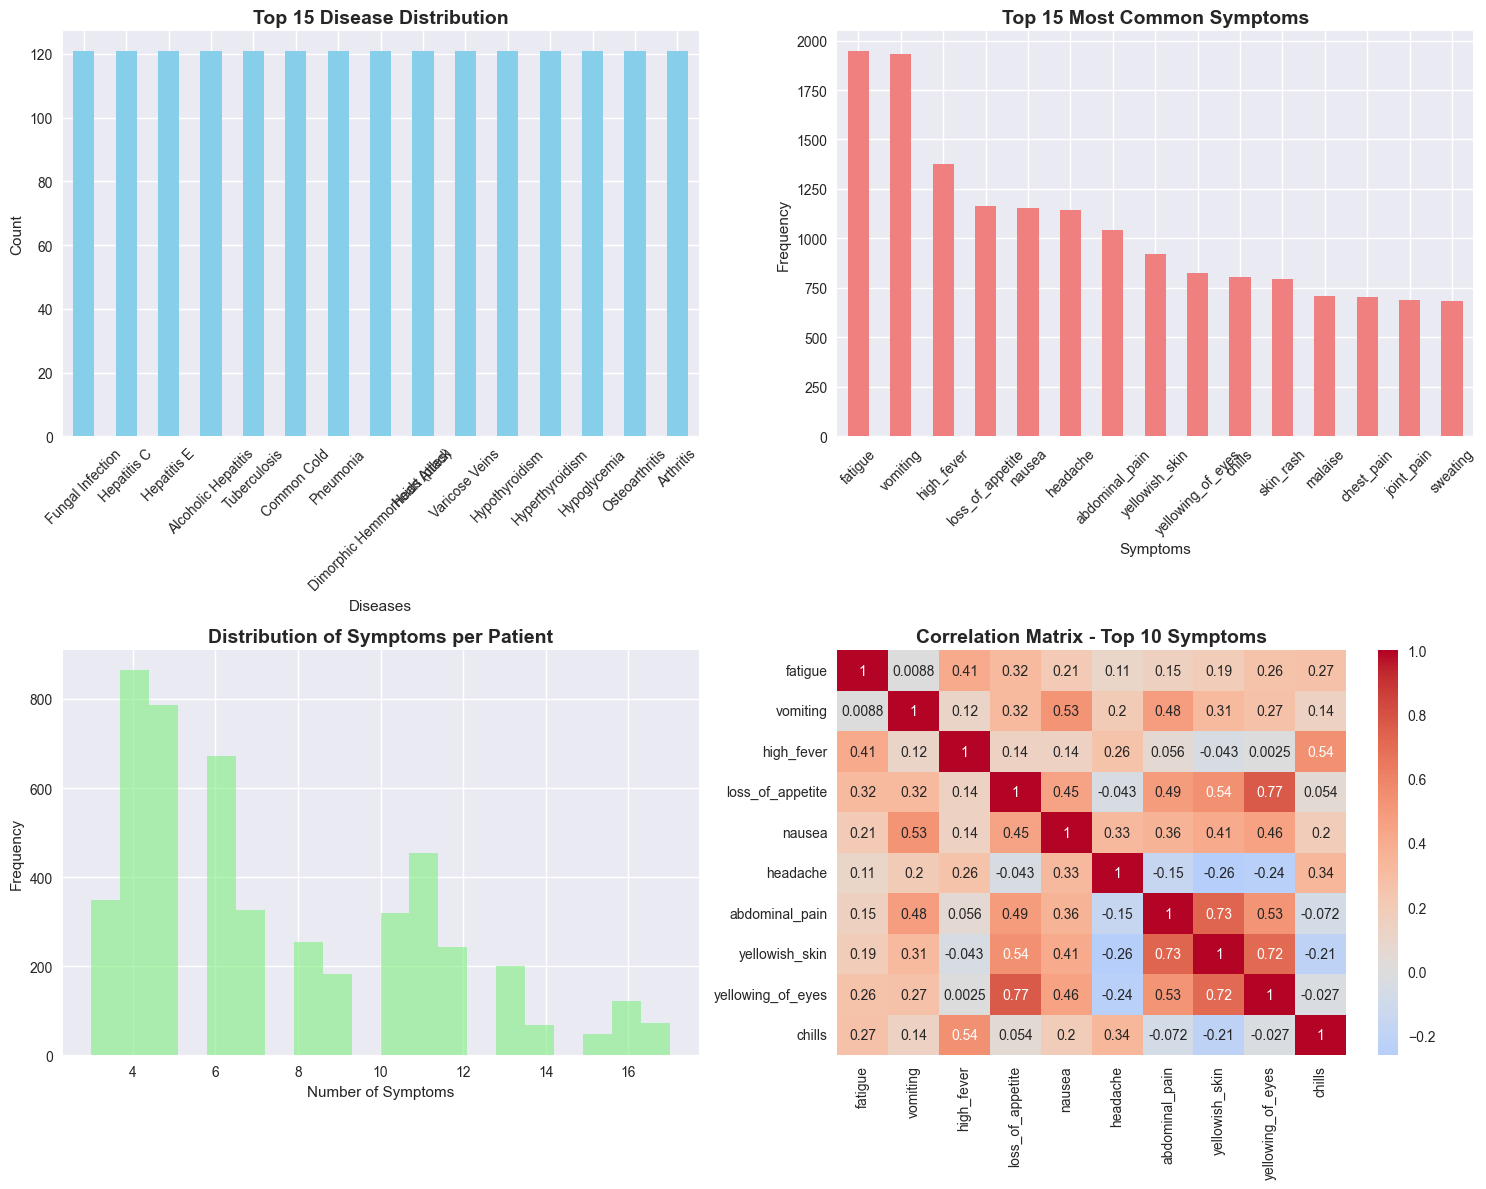

✅ Visualizations created successfully!


In [45]:
print("\n📈 DATA VISUALIZATION")
print("-" * 20)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

disease_counts.head(15).plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Top 15 Disease Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Diseases')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

symptom_freq.head(15).plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Top 15 Most Common Symptoms', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Symptoms')
axes[0,1].set_ylabel('Frequency')
axes[0,1].tick_params(axis='x', rotation=45)

symptoms_per_patient = df[symptom_cols].sum(axis=1)
axes[1,0].hist(symptoms_per_patient, bins=20, color='lightgreen', alpha=0.7)
axes[1,0].set_title('Distribution of Symptoms per Patient', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Symptoms')
axes[1,0].set_ylabel('Frequency')

top_symptoms = symptom_freq.head(10).index
corr_matrix = df[top_symptoms].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix - Top 10 Symptoms', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizations created successfully!")

In [47]:
X = df[symptom_cols]
y = df['prognosis']

In [49]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [51]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y_encoded.shape}")
print(f"Unique classes: {len(le.classes_)}")

Features shape: (4961, 132)
Target shape: (4961,)
Unique classes: 41


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [55]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (3968, 132)
Test set: (993, 132)


In [57]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'SVM': SVC(random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [59]:
cv_results = {}
cv_scores = {}

In [61]:
for name, model in models.items():
    # 5-fold cross-validation
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_score
    cv_scores[name] = cv_score.mean()
    print(f"{name}: {cv_score.mean():.4f} (+/- {cv_score.std() * 2:.4f})")

Random Forest: 1.0000 (+/- 0.0000)
XGBoost: 1.0000 (+/- 0.0000)
SVM: 1.0000 (+/- 0.0000)
Logistic Regression: 1.0000 (+/- 0.0000)
Naive Bayes: 1.0000 (+/- 0.0000)
KNN: 1.0000 (+/- 0.0000)
Decision Tree: 1.0000 (+/- 0.0000)
Gradient Boosting: 1.0000 (+/- 0.0000)


In [63]:
sorted_models = sorted(cv_scores.items(), key=lambda x: x[1], reverse=True)
print(f"\n🏆 Best performing model: {sorted_models[0][0]} with accuracy: {sorted_models[0][1]:.4f}")


🏆 Best performing model: Random Forest with accuracy: 1.0000


In [65]:
top_3_models = dict(sorted_models[:3])

tuned_models = {}

In [67]:
if 'Random Forest' in top_3_models:
    print("Tuning Random Forest...")
    rf_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
    rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    tuned_models['Random Forest'] = rf_grid.best_estimator_
    print(f"Best RF params: {rf_grid.best_params_}")

if 'XGBoost' in top_3_models:
    print("Tuning XGBoost...")
    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.1, 0.2]
    }
    xgb_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    tuned_models['XGBoost'] = xgb_grid.best_estimator_
    print(f"Best XGB params: {xgb_grid.best_params_}")

if 'SVM' in top_3_models:
    print("Tuning SVM...")
    svm_params = {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
    svm_grid = GridSearchCV(SVC(random_state=42, probability=True), svm_params, cv=3, scoring='accuracy', n_jobs=-1)
    svm_grid.fit(X_train, y_train)
    tuned_models['SVM'] = svm_grid.best_estimator_
    print(f"Best SVM params: {svm_grid.best_params_}")

Tuning Random Forest...
Best RF params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Tuning XGBoost...
Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Tuning SVM...
Best SVM params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


In [69]:
final_results = {}

for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    final_results[name] = accuracy
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Random Forest Results:
Accuracy: 1.0000
Classification Report:
                               precision    recall  f1-score   support

                         AIDS       1.00      1.00      1.00        24
                         Acne       1.00      1.00      1.00        24
          Alcoholic Hepatitis       1.00      1.00      1.00        24
                      Allergy       1.00      1.00      1.00        24
                    Arthritis       1.00      1.00      1.00        24
             Bronchial Asthma       1.00      1.00      1.00        24
         Cervical Spondylosis       1.00      1.00      1.00        24
                   Chickenpox       1.00      1.00      1.00        25
          Chronic Cholestasis       1.00      1.00      1.00        24
                  Common Cold       1.00      1.00      1.00        24
                       Dengue       1.00      1.00      1.00        25
                    Diabetes        1.00      1.00      1.00        24
Dimorphic He

In [71]:
best_model_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_model_name]
best_accuracy = final_results[best_model_name]

print(f"\n🎯 BEST MODEL: {best_model_name}")
print(f"🎯 BEST ACCURACY: {best_accuracy:.4f}")


🎯 BEST MODEL: Random Forest
🎯 BEST ACCURACY: 1.0000


Top 15 Most Important Features:
                         feature  importance
108                 rusty_sputum    0.021772
118              blood_in_sputum    0.015984
104           increased_appetite    0.015425
101        abnormal_menstruation    0.015169
100                   belly_pain    0.014588
109        lack_of_concentration    0.014449
111  receiving_blood_transfusion    0.014131
36          pain_behind_the_eyes    0.013973
113                         coma    0.013745
97                   muscle_pain    0.013555
41                    mild_fever    0.013087
114             stomach_bleeding    0.012812
77                slurred_speech    0.012608
58               fast_heart_rate    0.012176
73           swollen_extremeties    0.012110


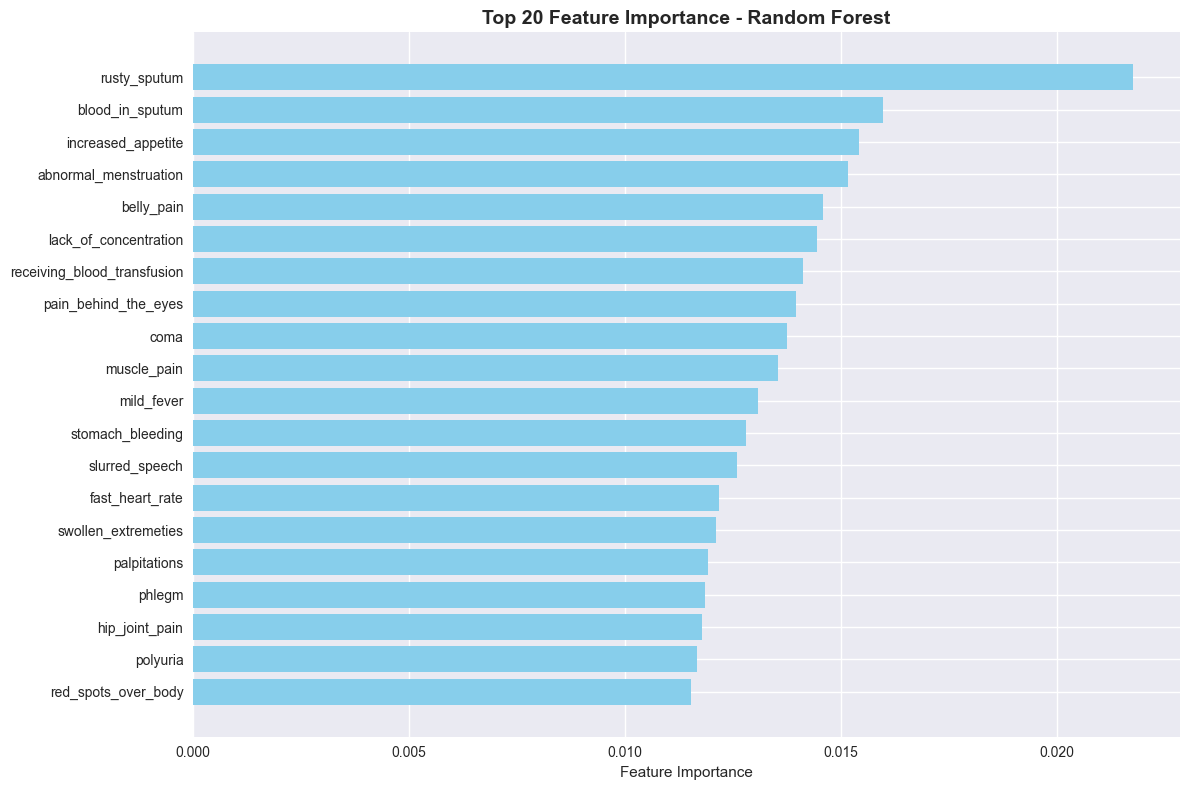

In [73]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': symptom_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top 15 Most Important Features:")
    print(feature_importance.head(15))
    
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='skyblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

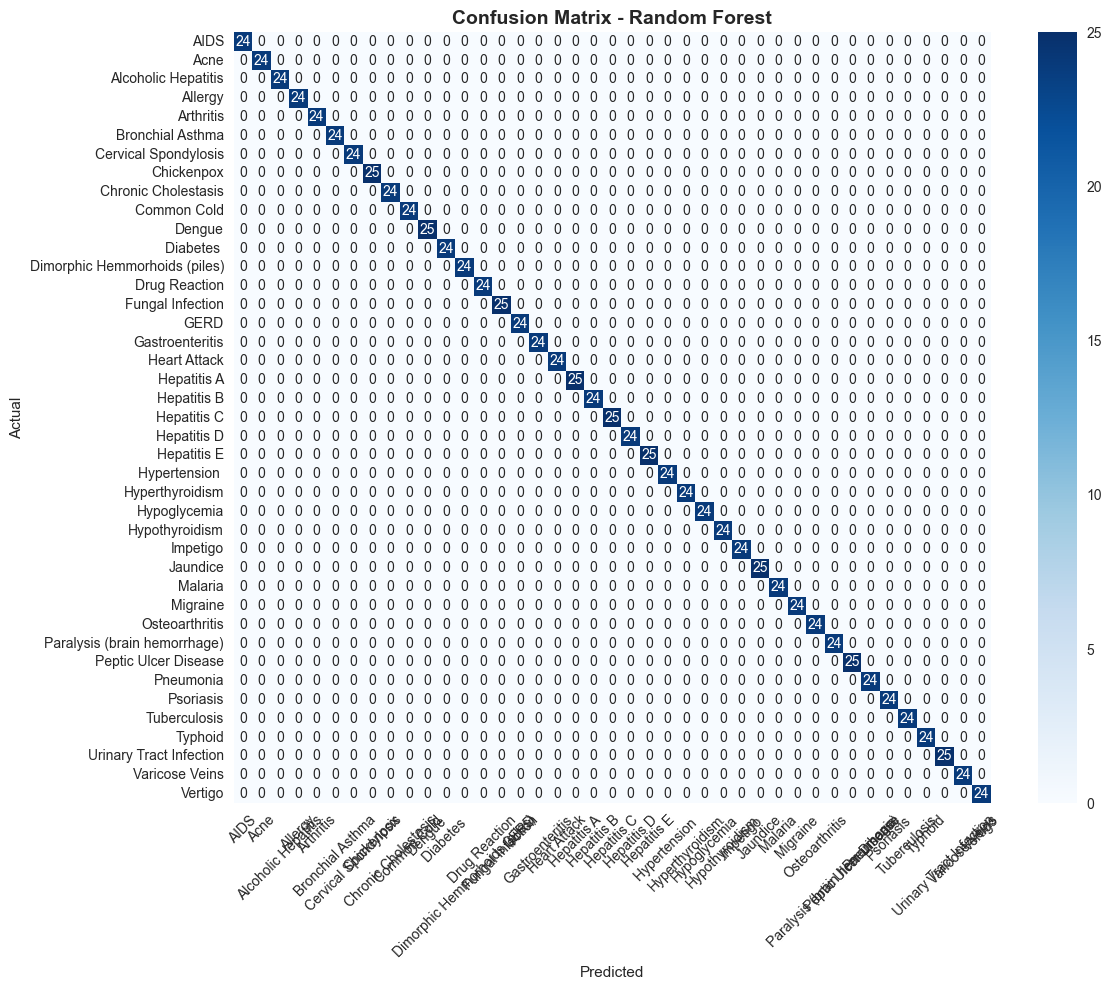

In [75]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
ensemble_models = list(tuned_models.values())[:3]
ensemble_names = list(tuned_models.keys())[:3]

voting_classifier = VotingClassifier(
    estimators=[(name, model) for name, model in zip(ensemble_names, ensemble_models)],
    voting='soft'
)

voting_classifier.fit(X_train, y_train)
ensemble_pred = voting_classifier.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)

print(f"Ensemble Model Accuracy: {ensemble_accuracy:.4f}")
print(f"Ensemble Components: {ensemble_names}")

Ensemble Model Accuracy: 1.0000
Ensemble Components: ['Random Forest', 'XGBoost', 'SVM']


In [79]:
def predict_disease(symptoms_input, model=best_model, label_encoder=le, feature_names=symptom_cols):
    input_vector = np.zeros(len(feature_names))
    
    for symptom, value in symptoms_input.items():
        if symptom in feature_names:
            idx = feature_names.index(symptom)
            input_vector[idx] = value
    
    input_vector = input_vector.reshape(1, -1)
    
    prediction = model.predict(input_vector)[0]
    probability = model.predict_proba(input_vector)[0]
    
    disease_name = label_encoder.inverse_transform([prediction])[0]
    confidence = max(probability)
    
    return disease_name, confidence

In [83]:
example_symptoms = {
    'itching': 1,
    'skin_rash': 1,
    'nodal_skin_eruptions': 1
}

predicted_disease, confidence = predict_disease(example_symptoms)
print(f"Example Prediction:")
print(f"Symptoms: {example_symptoms}")
print(f"Predicted Disease: {predicted_disease}")
print(f"Confidence: {confidence:.4f}")

Example Prediction:
Symptoms: {'itching': 1, 'skin_rash': 1, 'nodal_skin_eruptions': 1}
Predicted Disease: Fungal Infection
Confidence: 0.0930


In [87]:
print(f"🏆 Best Model: {best_model_name}")
print(f"🎯 Best Accuracy: {best_accuracy:.4f}")
print(f"📊 Dataset Size: {len(df)} samples")
print(f"🔢 Features: {len(symptom_cols)} symptoms")
print(f"🏥 Diseases: {len(le.classes_)} different conditions")

🏆 Best Model: Random Forest
🎯 Best Accuracy: 1.0000
📊 Dataset Size: 4961 samples
🔢 Features: 132 symptoms
🏥 Diseases: 41 different conditions


In [89]:
if ensemble_accuracy > best_accuracy:
    final_model = voting_classifier
    print("✅ Ensemble model selected for deployment.")
else:
    final_model = best_model
    print("✅ Best single model selected for deployment.")

✅ Best single model selected for deployment.


In [91]:
import pickle

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('symptom_cols.pkl', 'wb') as f:
    pickle.dump(symptom_cols, f)